In [24]:
import warnings
warnings.filterwarnings('ignore')
import keras
from keras.datasets import mnist #MINIST DATABASE 60.000 imagens de treino e 10.000 de teste

In [25]:
(x_treino, y_treino), (x_teste, y_teste) = mnist.load_data() #padrao de importação dos dados

In [26]:
y_treino.shape

(60000,)

In [27]:
from tensorflow.python.keras.utils import np_utils
y_treino_convertido = np_utils.to_categorical(y_treino) #convertendo a coluna de valores em uma matriz de classes #10 colunas
y_teste_convertido = np_utils.to_categorical(y_teste)

In [28]:
y_treino_convertido

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], dtype=float32)

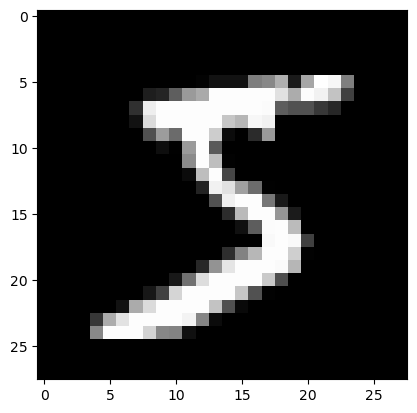

In [29]:
import matplotlib.pyplot as plt
plt.imshow(x_treino[0], cmap='gray')

In [30]:
x_treino[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [31]:
from keras.models import Sequential
from keras.layers import Dense, Activation

In [32]:
x_treino.shape

(60000, 28, 28)

In [33]:
x_treino_remodelado = x_treino.reshape((60000, 784)) #28 x 28
x_teste_remodelado = x_teste.reshape((10000, 784))

In [34]:
x_treino_normalizado = x_treino_remodelado.astype('float32') / 255 #dividir todos paras 255

In [35]:
x_teste_normalizado = x_teste_remodelado.astype('float32') / 255

In [36]:
x_treino_normalizado[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [37]:
modelo = Sequential()
modelo.add(Dense(30, input_dim=784, kernel_initializer='normal', activation='relu')) #Entrada & primeira camada oculta
modelo.add(Dense(30, kernel_initializer='normal', activation='relu')) #Segunda camada oculta
modelo.add(Dense(10, kernel_initializer='normal', activation='softmax')) #Saida

In [38]:
from keras.optimizers import SGD
otimizador = SGD()

In [39]:
modelo.compile(loss='categorical_crossentropy', optimizer=otimizador, metrics=['acc']) #"acc" é a métrica de acurácia
historico = modelo.fit(x_treino_normalizado, y_treino_convertido, epochs=200, batch_size=100, validation_data=(x_teste_normalizado, y_teste_convertido), verbose=1)

Epoch 1/200
600/600 [==============================] - 1s 2ms/step - loss: 2.2923 - acc: 0.1515 - val_loss: 2.2762 - val_acc: 0.1740
Epoch 2/200
600/600 [==============================] - 1s 1ms/step - loss: 2.1791 - acc: 0.2762 - val_loss: 1.9279 - val_acc: 0.4730
Epoch 3/200
600/600 [==============================] - 1s 1ms/step - loss: 1.3942 - acc: 0.5943 - val_loss: 0.9644 - val_acc: 0.7055
Epoch 4/200
600/600 [==============================] - 1s 1ms/step - loss: 0.8131 - acc: 0.7461 - val_loss: 0.6941 - val_acc: 0.7895
Epoch 5/200
600/600 [==============================] - 1s 2ms/step - loss: 0.6514 - acc: 0.8008 - val_loss: 0.5872 - val_acc: 0.8246
Epoch 6/200
600/600 [==============================] - 1s 1ms/step - loss: 0.5593 - acc: 0.8352 - val_loss: 0.5043 - val_acc: 0.8524
Epoch 7/200
600/600 [==============================] - 1s 2ms/step - loss: 0.4902 - acc: 0.8589 - val_loss: 0.4492 - val_acc: 0.8668
Epoch 8/200
600/600 [==============================] - 1s 1ms/step - 

600/600 [==============================] - 1s 1ms/step - loss: 0.1181 - acc: 0.9659 - val_loss: 0.1363 - val_acc: 0.9611
Epoch 63/200
600/600 [==============================] - 1s 1ms/step - loss: 0.1169 - acc: 0.9665 - val_loss: 0.1358 - val_acc: 0.9607
Epoch 64/200
600/600 [==============================] - 1s 1ms/step - loss: 0.1157 - acc: 0.9671 - val_loss: 0.1360 - val_acc: 0.9606
Epoch 65/200
600/600 [==============================] - 1s 1ms/step - loss: 0.1143 - acc: 0.9676 - val_loss: 0.1332 - val_acc: 0.9623
Epoch 66/200
600/600 [==============================] - 1s 1ms/step - loss: 0.1131 - acc: 0.9672 - val_loss: 0.1326 - val_acc: 0.9621
Epoch 67/200
600/600 [==============================] - 1s 1ms/step - loss: 0.1119 - acc: 0.9679 - val_loss: 0.1344 - val_acc: 0.9615
Epoch 68/200
600/600 [==============================] - 1s 1ms/step - loss: 0.1106 - acc: 0.9684 - val_loss: 0.1318 - val_acc: 0.9622
Epoch 69/200
600/600 [==============================] - 1s 1ms/step - loss:

600/600 [==============================] - 1s 1ms/step - loss: 0.0698 - acc: 0.9797 - val_loss: 0.1165 - val_acc: 0.9667
Epoch 124/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0693 - acc: 0.9801 - val_loss: 0.1176 - val_acc: 0.9660
Epoch 125/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0688 - acc: 0.9801 - val_loss: 0.1159 - val_acc: 0.9664
Epoch 126/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0684 - acc: 0.9804 - val_loss: 0.1153 - val_acc: 0.9664
Epoch 127/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0680 - acc: 0.9805 - val_loss: 0.1169 - val_acc: 0.9656
Epoch 128/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0673 - acc: 0.9807 - val_loss: 0.1161 - val_acc: 0.9671
Epoch 129/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0667 - acc: 0.9810 - val_loss: 0.1159 - val_acc: 0.9667
Epoch 130/200
600/600 [==============================] - 1s 1ms/step 

Epoch 184/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0469 - acc: 0.9874 - val_loss: 0.1177 - val_acc: 0.9671
Epoch 185/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0466 - acc: 0.9870 - val_loss: 0.1177 - val_acc: 0.9660
Epoch 186/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0463 - acc: 0.9874 - val_loss: 0.1185 - val_acc: 0.9667
Epoch 187/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0461 - acc: 0.9874 - val_loss: 0.1187 - val_acc: 0.9662
Epoch 188/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0458 - acc: 0.9877 - val_loss: 0.1211 - val_acc: 0.9659
Epoch 189/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0453 - acc: 0.9880 - val_loss: 0.1198 - val_acc: 0.9660
Epoch 190/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0452 - acc: 0.9877 - val_loss: 0.1198 - val_acc: 0.9656
Epoch 191/200
600/600 [==============================] 

In [40]:
historico.history[ 'acc' ]

[0.15148332715034485,
 0.27623334527015686,
 0.5942833423614502,
 0.7461166381835938,
 0.8007500171661377,
 0.8351500034332275,
 0.8588833212852478,
 0.8739666938781738,
 0.8840500116348267,
 0.8916000127792358,
 0.8970333337783813,
 0.9023000001907349,
 0.9060999751091003,
 0.9101333618164062,
 0.913183331489563,
 0.9163333177566528,
 0.9189000129699707,
 0.9215333461761475,
 0.9244499802589417,
 0.9264666438102722,
 0.9284999966621399,
 0.9309666752815247,
 0.9333000183105469,
 0.9348333477973938,
 0.9365833401679993,
 0.9381999969482422,
 0.9398833513259888,
 0.9415666460990906,
 0.942466676235199,
 0.9441499710083008,
 0.9454333186149597,
 0.9469000101089478,
 0.947700023651123,
 0.9486333131790161,
 0.9494666457176208,
 0.9499833583831787,
 0.9509833455085754,
 0.9519666433334351,
 0.953249990940094,
 0.9537666440010071,
 0.9550333619117737,
 0.9555333256721497,
 0.9562833309173584,
 0.9565666913986206,
 0.9573500156402588,
 0.9585333466529846,
 0.9587500095367432,
 0.959466695785

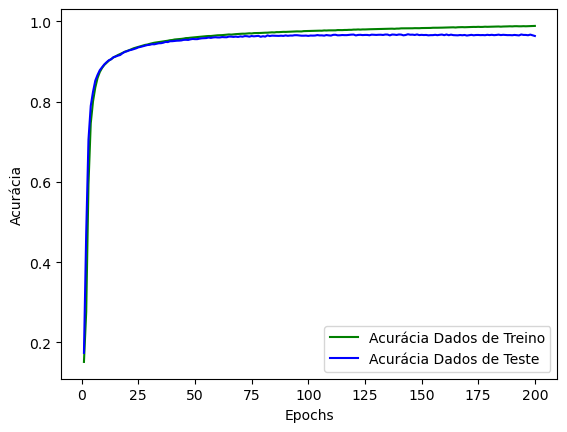

In [41]:
acuracia_treino = historico.history['acc']
acuracia_teste = historico.history['val_acc']

epochs = range(1, len(acuracia_treino)+1)

plt.plot(epochs, acuracia_treino, '-g', label='Acurácia Dados de Treino') # g é a cor
plt.plot(epochs, acuracia_teste, '-b', label='Acurácia Dados de Teste')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Acurácia')
plt.show()